In [3]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Inspection

In [4]:
raw_data = pd.read_csv("../01_data/raw_full.csv")

display(raw_data.head(5))
raw_data.info()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [5]:
for col in raw_data.select_dtypes(include="float64").columns:
    invalid = raw_data.loc[raw_data[col] % 1 != 0, col]
    print(f"{col}: {len(invalid)} non-integer values")
    if len(invalid) > 0:
        display(invalid.head())

Region_Code: 0 non-integer values
Annual_Premium: 0 non-integer values
Policy_Sales_Channel: 0 non-integer values


In [6]:
df = raw_data.copy()

# Drop id column
df = df.drop(columns="id")

# Convert float columns containing only whole numbers to integers
float_cols = df.select_dtypes(include="float64").columns
raw_data[float_cols] = df[float_cols].astype(int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381109 non-null  str    
 1   Age                   381109 non-null  int64  
 2   Driving_License       381109 non-null  int64  
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64  
 5   Vehicle_Age           381109 non-null  str    
 6   Vehicle_Damage        381109 non-null  str    
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64  
 10  Response              381109 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 32.0 MB


In [7]:
# Identify duplicate rows after removing the unique identifier
duplicate_rows = df[df.duplicated(keep=False)]

# Calculate summary statistics
num_duplicate_rows = len(duplicate_rows)
num_duplicate_pairs = duplicate_rows.groupby(df.columns.tolist()).ngroups
duplicate_percentage = (num_duplicate_rows / len(df)) * 100

print(f"Duplicate rows identified: {num_duplicate_rows}")
print(f"Duplicate pairs identified: {num_duplicate_pairs}")
print(f"Percentage of dataset: {duplicate_percentage:.3f}%")

print("\nFrequency of duplicate group sizes:")
display(duplicate_rows.groupby(df.columns.tolist()).size().value_counts())

print("\nResponse distribution among duplicate rows:")
display(duplicate_rows["Response"].value_counts())

# Measure separation between duplicate pairs
pairs = (
    duplicate_rows
    .reset_index()
    .groupby(df.columns.tolist())["index"]
    .apply(list)
)

pair_distances = pairs.apply(lambda x: abs(x[1] - x[0]))

print("\nDistance (in rows) between members of each duplicate pair:")
display(pair_distances.describe())

Duplicate rows identified: 538
Duplicate pairs identified: 269
Percentage of dataset: 0.141%

Frequency of duplicate group sizes:


2    269
Name: count, dtype: int64


Response distribution among duplicate rows:


Response
0    488
1     50
Name: count, dtype: int64


Distance (in rows) between members of each duplicate pair:


count       269.000000
mean     123530.910781
std       92509.077228
min         558.000000
25%       44617.000000
50%      106732.000000
75%      185897.000000
max      353417.000000
Name: index, dtype: float64

After removing the unique identifier (id), 269 duplicate customer profiles (538 observations) were identified, representing approximately 0.14% of the dataset. Further investigation showed that duplicate pairs included both response classes and were separated by widely varying distances within the dataset (minimum separation = 558 rows; median = 106,732 rows; maximum = 353,417 rows). Because the duplicates were dispersed throughout the dataset rather than occurring in contiguous blocks or at regular intervals, they were considered likely to represent distinct customers with identical recorded characteristics rather than data generation or import errors. Therefore, the duplicate observations were retained.

In [8]:
df.describe().round(2)

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00
mean,38.82,1.00,26.39,0.46,30564.39,112.03,154.35,0.12
std,15.51,0.05,13.23,0.50,17213.16,54.20,83.67,0.33
min,20.00,0.00,0.00,0.00,2630.00,1.00,10.00,0.00
25%,25.00,1.00,15.00,0.00,24405.00,29.00,82.00,0.00
50%,36.00,1.00,28.00,0.00,31669.00,133.00,154.00,0.00
75%,49.00,1.00,35.00,1.00,39400.00,152.00,227.00,0.00
max,85.00,1.00,52.00,1.00,540165.00,163.00,299.00,1.00


In [9]:
for col in df.select_dtypes(include="str").columns:
    print(f"\n")
    print(df[col].value_counts())



Gender
Male      206089
Female    175020
Name: count, dtype: int64


Vehicle_Age
1-2 Year     200316
< 1 Year     164786
> 2 Years     16007
Name: count, dtype: int64


Vehicle_Damage
Yes    192413
No     188696
Name: count, dtype: int64


# EDA

/var/folders/bb/9wscb13j3ml205njxw9_qtmh0000gn/T/ipykernel_58951/3934928395.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[col], vert=True)


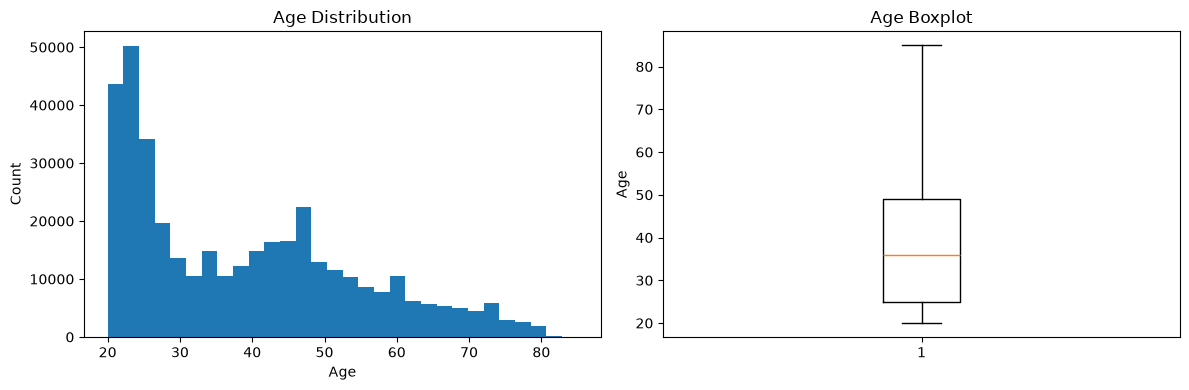

/var/folders/bb/9wscb13j3ml205njxw9_qtmh0000gn/T/ipykernel_58951/3934928395.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[col], vert=True)


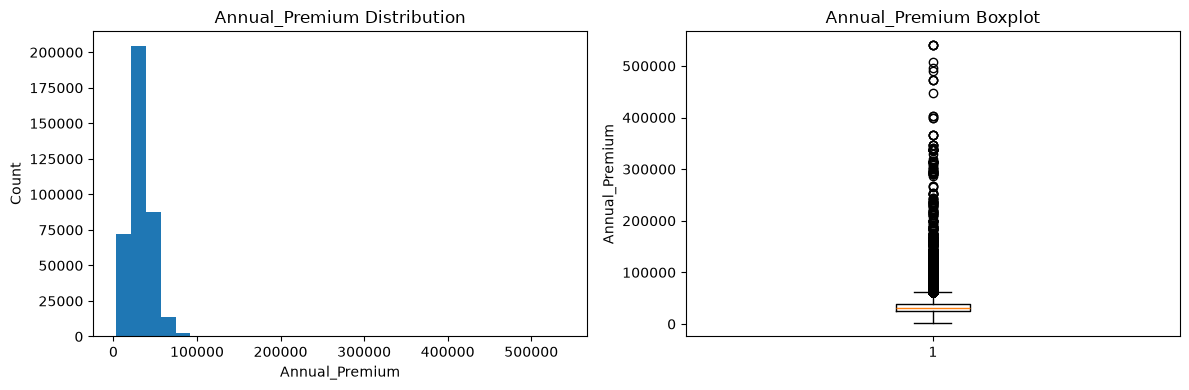

/var/folders/bb/9wscb13j3ml205njxw9_qtmh0000gn/T/ipykernel_58951/3934928395.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[col], vert=True)


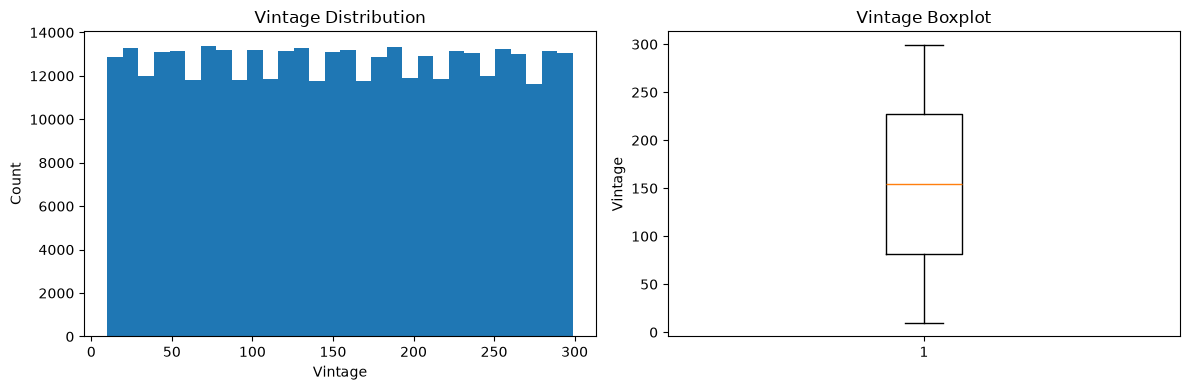

In [10]:
continuous_cols = [
    "Age",
    "Annual_Premium",
    "Vintage"
]

import matplotlib.pyplot as plt

for col in continuous_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    ax[0].hist(df[col], bins=30)
    ax[0].set_title(f"{col} Distribution")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    # Boxplot
    ax[1].boxplot(df[col], vert=True)
    ax[1].set_title(f"{col} Boxplot")
    ax[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [11]:
vehicle_order = [
    "< 1 Year",
    "1-2 Year",
    "> 2 Years"
]

df["Vehicle_Age"] = pd.Categorical(
    df["Vehicle_Age"],
    categories=vehicle_order,
    ordered=True
)

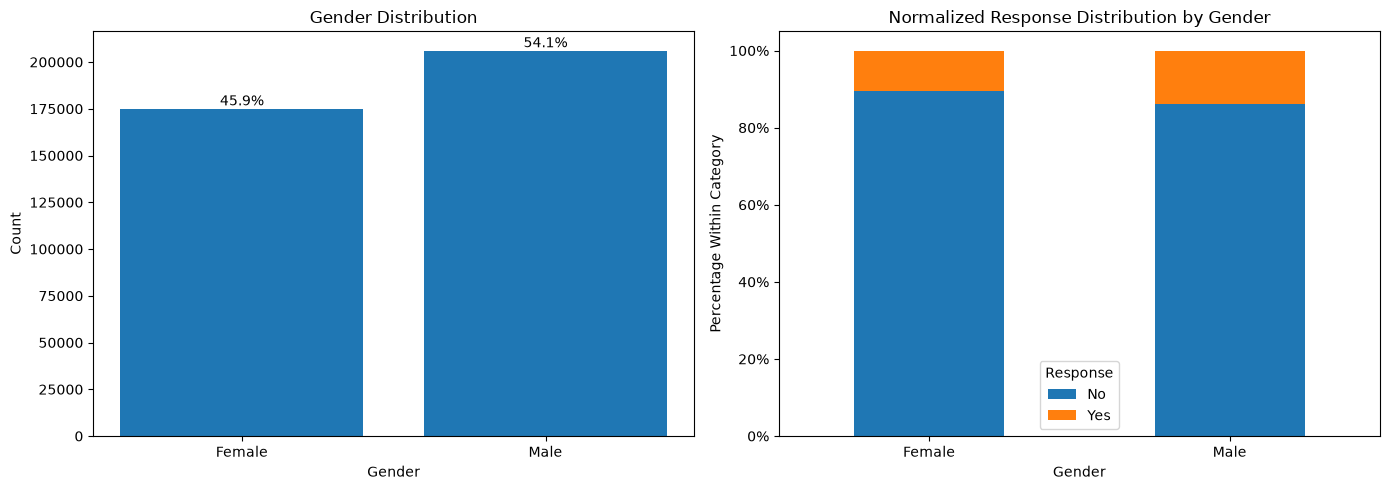

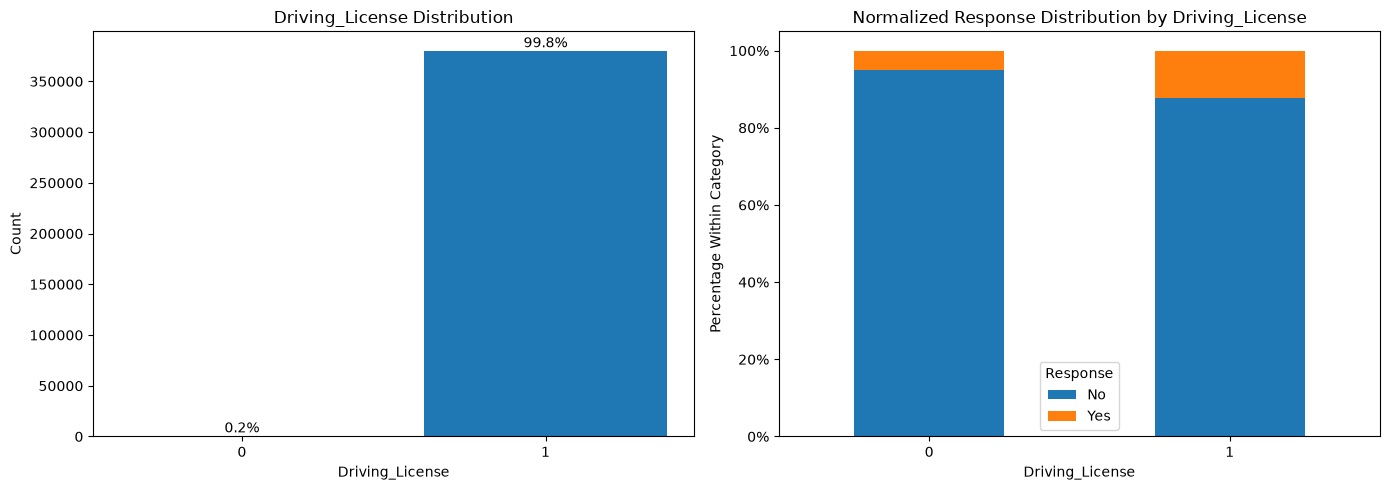

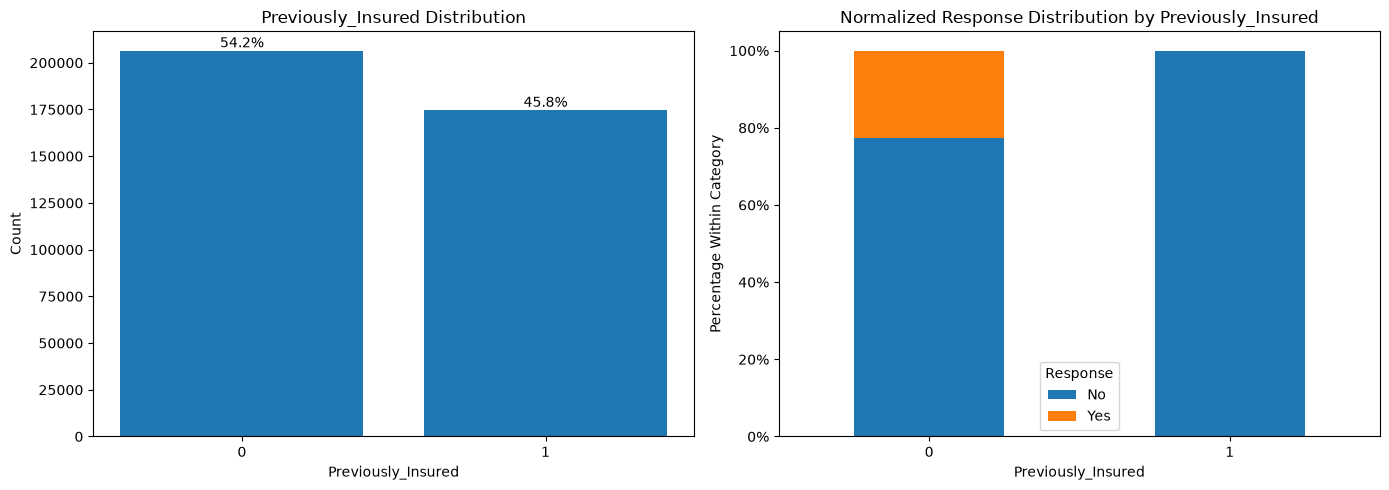

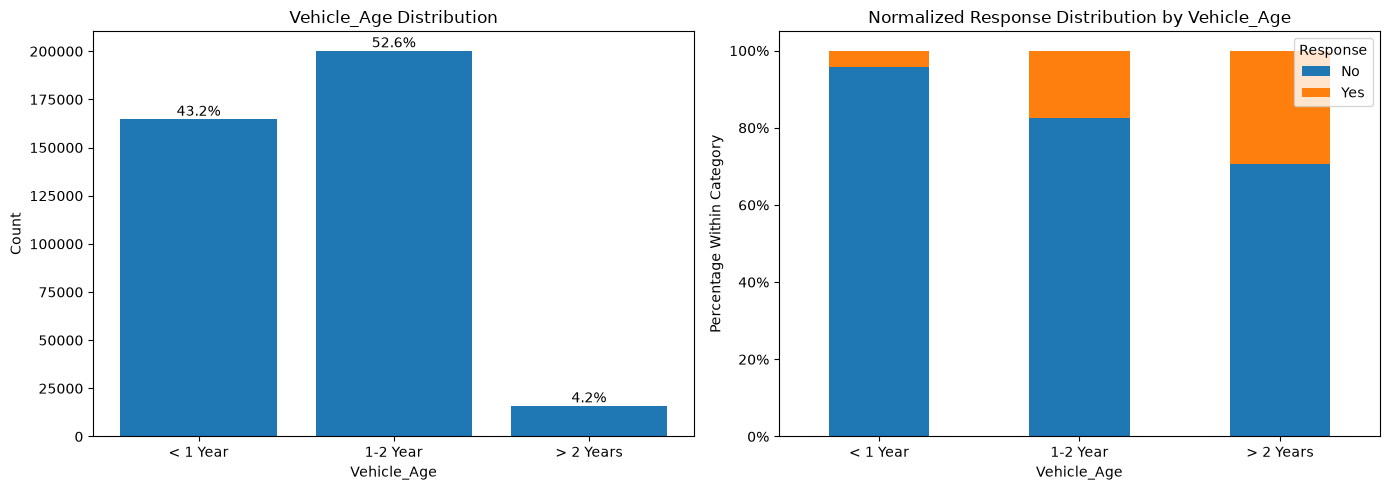

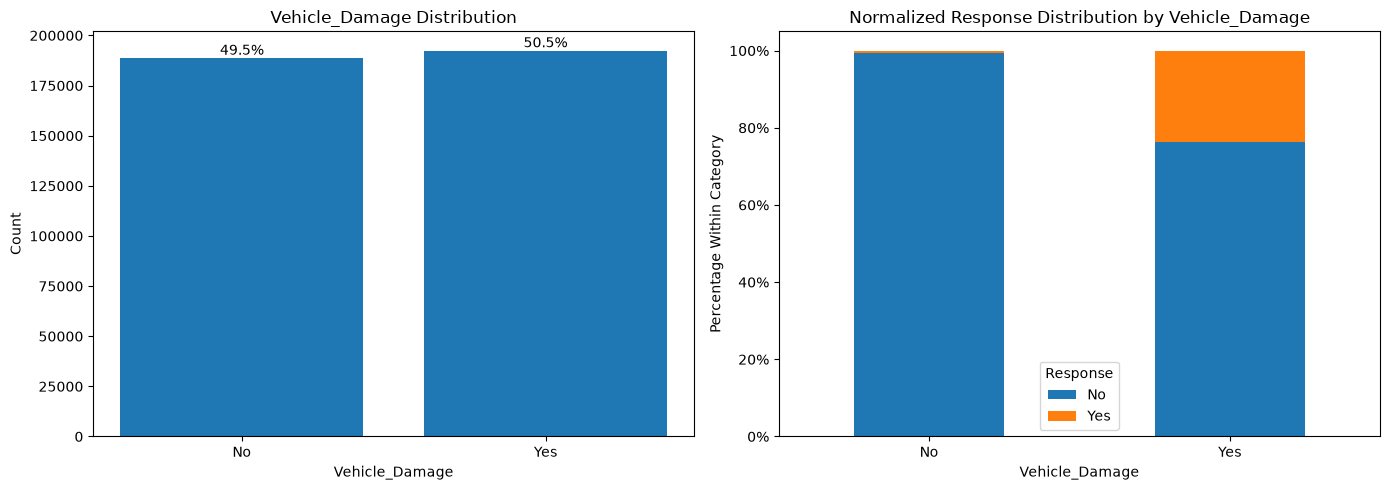

In [12]:
from matplotlib.ticker import PercentFormatter

small_categorical = [
    "Gender",
    "Driving_License",
    "Previously_Insured",
    "Vehicle_Age",
    "Vehicle_Damage"
]

for col in small_categorical:

    # Overall category distribution
    counts = df[col].value_counts().sort_index()
    percentages = counts / len(df)

    # Response distribution within each category
    response_dist = pd.crosstab(
        df[col],
        df["Response"],
        normalize="index"
    ).sort_index()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 5)
    )

    # -----------------------------
    # Left: overall distribution
    # -----------------------------
    bars = axes[0].bar(
        counts.index.astype(str),
        counts.values
    )

    axes[0].set_title(f"{col} Distribution")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    for bar, pct in zip(bars, percentages):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1%}",
            ha="center",
            va="bottom"
        )

    # -----------------------------
    # Right: normalized response
    # -----------------------------
    response_dist.plot(
        kind="bar",
        stacked=True,
        ax=axes[1]
    )

    axes[1].set_title(f"Normalized Response Distribution by {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Percentage Within Category")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(
        title="Response",
        labels=["No", "Yes"]
    )

    plt.tight_layout()
    plt.show()

In [13]:
dl_counts = pd.crosstab(
    df["Driving_License"],
    df["Response"]
)

dl_counts.index = ["No", "Yes"]
dl_counts.columns = ["No", "Yes"]
dl_counts.index.name = "Driving License"
dl_counts.columns.name = "Response"

print("Contingency Table: Driving License vs. Response")
display(dl_counts)

dl_props = pd.crosstab(
    df["Driving_License"],
    df["Response"],
    normalize="index"
)

dl_props.index = ["No", "Yes"]
dl_props.columns = ["No", "Yes"]
dl_props.index.name = "Driving License"
dl_props.columns.name = "Response"

print("Row-Normalized Proportions: Driving License vs. Response")
display(dl_props.style.format("{:.2%}"))

Contingency Table: Driving License vs. Response


Response,No,Yes
Driving License,,
No,771,41
Yes,333628,46669


Row-Normalized Proportions: Driving License vs. Response


Response,No,Yes
Driving License,,
No,94.95%,5.05%
Yes,87.73%,12.27%


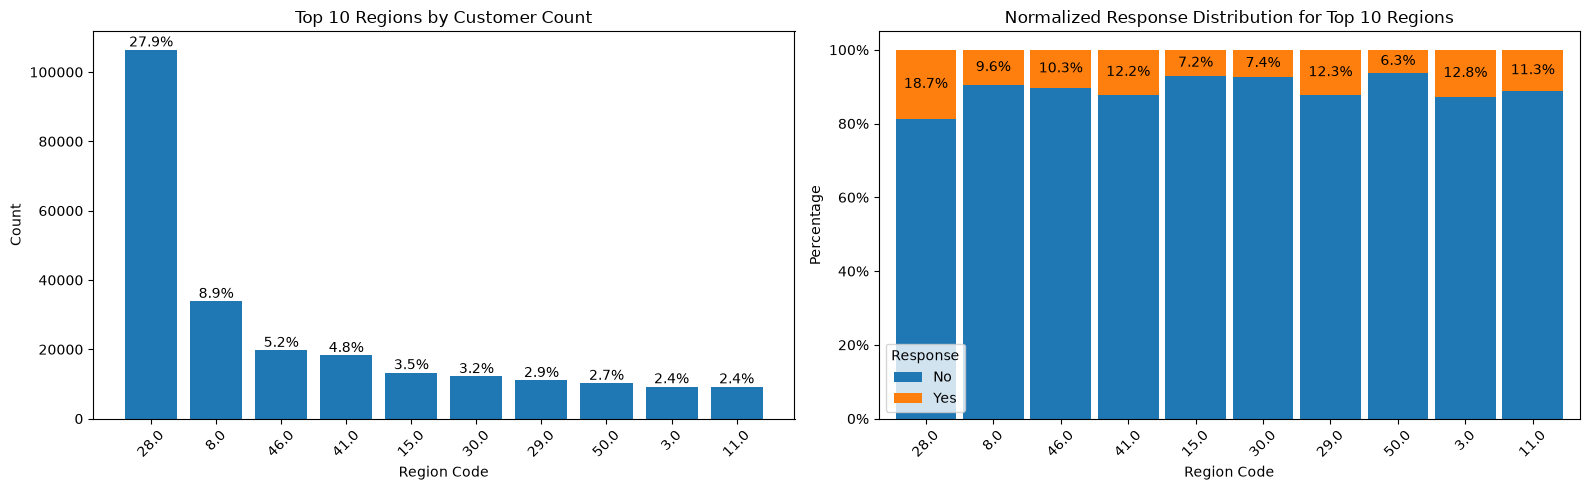

In [14]:
top_n = 10

region_counts = (
    df["Region_Code"]
      .value_counts()
      .head(top_n)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -----------------------------
# Left: Top regions by frequency
# -----------------------------
left_bars = axes[0].bar(
    region_counts.index.astype(str),
    region_counts.values
)

axes[0].set_title(f"Top {top_n} Regions by Customer Count")
axes[0].set_xlabel("Region Code")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Percentage of the entire dataset represented by each region
region_percentages = region_counts / len(df)

for bar, pct in zip(left_bars, region_percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1%}",
        ha="center",
        va="bottom"
    )

# -----------------------------
# Right: Normalized response distribution
# -----------------------------
region_response = (
    pd.crosstab(
        df["Region_Code"],
        df["Response"],
        normalize="index"
    )
    .loc[region_counts.index]
    .reindex(columns=[0, 1], fill_value=0)
)

region_response.plot(
    kind="bar",
    stacked=True,
    width=0.9,
    ax=axes[1]
)

axes[1].set_title(
    f"Normalized Response Distribution for Top {top_n} Regions"
)
axes[1].set_xlabel("Region Code")
axes[1].set_ylabel("Percentage")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(
    title="Response",
    labels=["No", "Yes"]
)

# Place each Yes percentage in the center of the orange segment
for i, rate in enumerate(region_response[1]):
    axes[1].text(
        i,
        1 - rate / 2,
        f"{rate:.1%}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

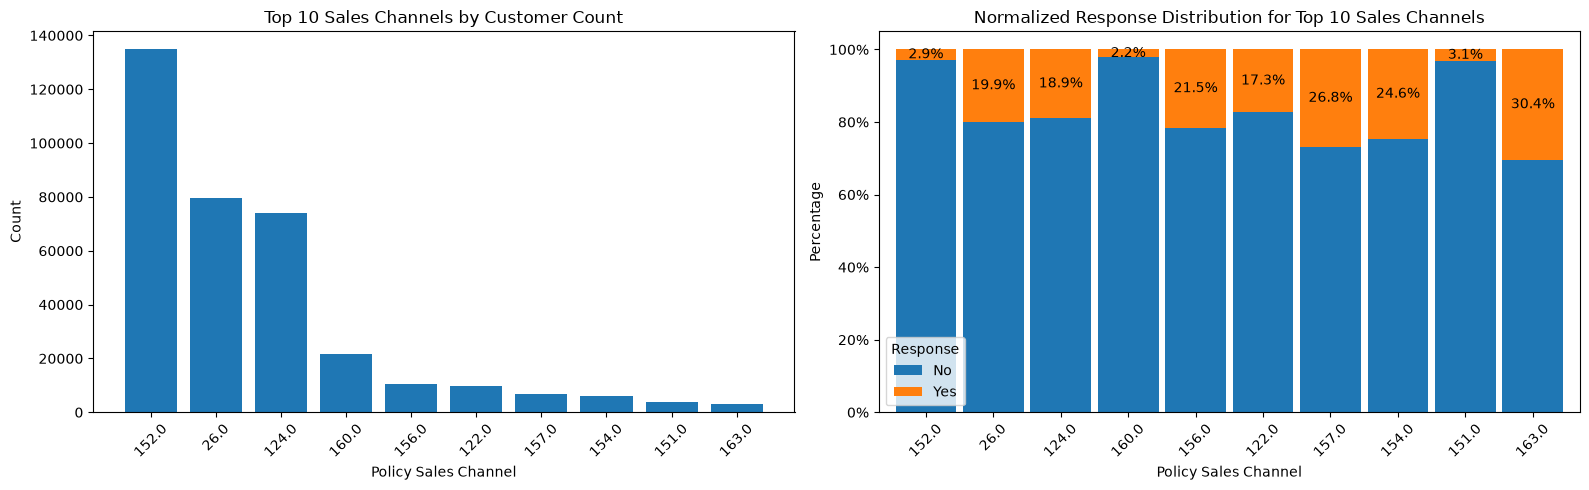

In [15]:
top_n = 10

channel_counts = df["Policy_Sales_Channel"].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -----------------------------
# Left: Top regions by frequency
# -----------------------------
axes[0].bar(
    channel_counts.index.astype(str),
    channel_counts.values
)

axes[0].set_title(f"Top {top_n} Sales Channels by Customer Count")
axes[0].set_xlabel("Policy Sales Channel")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# -----------------------------
# Right: Response rate
# -----------------------------
channel_response = (
    pd.crosstab(
        df["Policy_Sales_Channel"],
        df["Response"],
        normalize="index"
    )
    .loc[channel_counts.index]
)

channel_response.plot(
    kind="bar",
    stacked=True,
    width=0.9,
    ax=axes[1]
)

axes[1].set_title(
    f"Normalized Response Distribution for Top {top_n} Sales Channels"
)
axes[1].set_xlabel("Policy Sales Channel")
axes[1].set_ylabel("Percentage")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(
    title="Response",
    labels=["No", "Yes"]
)

for i, rate in enumerate(channel_response[1]):
    axes[1].text(
        i,
        1 - rate / 2,
        f"{rate:.1%}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

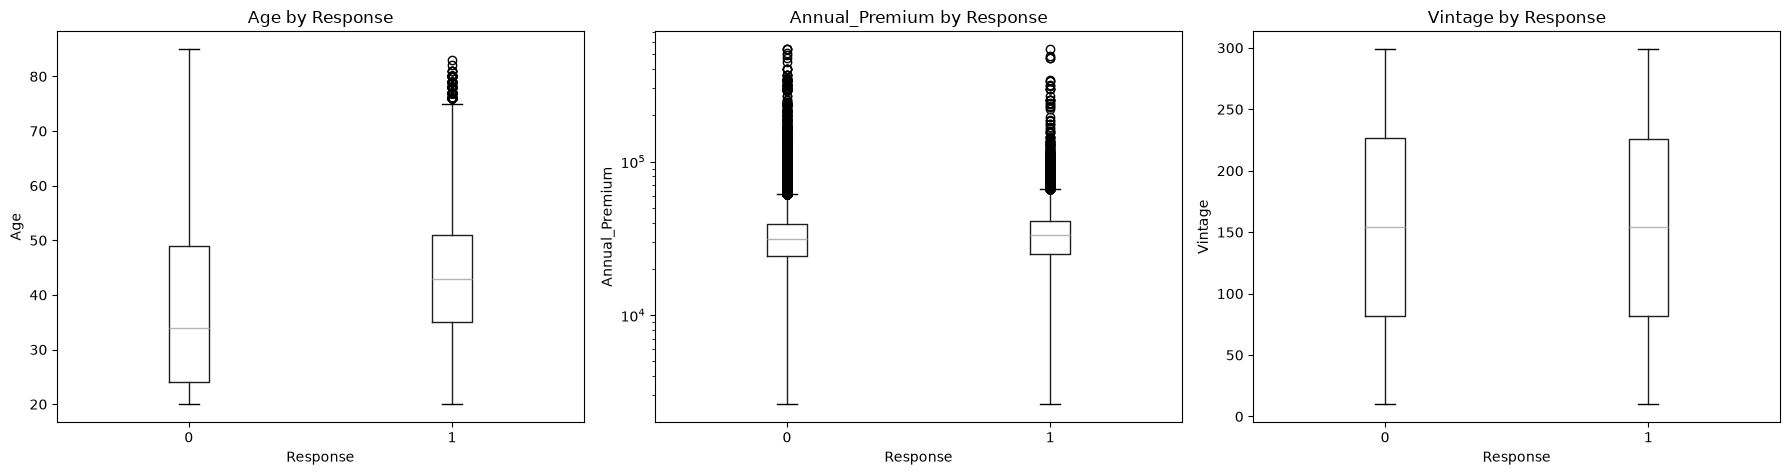

In [16]:
numeric_cols = ["Age", "Annual_Premium", "Vintage"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    df.boxplot(
        column=col,
        by="Response",
        ax=ax,
        grid=False
    )

    ax.set_title(f"{col} by Response")
    ax.set_xlabel("Response")
    ax.set_ylabel(col)

axes[1].set_yscale("log")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [17]:
numeric_cols = [
    "Age",
    "Annual_Premium",
    "Vintage",
    "Response"
]

correlation_matrix = df[numeric_cols].corr()

display(correlation_matrix)

,Age,Annual_Premium,Vintage,Response
Age,1.000000,0.067507,-0.001264,0.111147
Annual_Premium,0.067507,1.000000,-0.000608,0.022575
Vintage,-0.001264,-0.000608,1.000000,-0.001050
Response,0.111147,0.022575,-0.001050,1.000000


In [18]:
response_counts = df["Response"].value_counts()
response_proportions = df["Response"].value_counts(normalize=True)

display(
    pd.DataFrame({
        "Count": response_counts,
        "Proportion": response_proportions
    })
)

,Count,Proportion
Response,,
0,334399,0.877437
1,46710,0.122563


# Modeling

In [55]:
# Split into train and test sets

from sklearn.model_selection import train_test_split

df_model = df.copy()

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["Response"],
    random_state=42
)

print(f"Training set: {train_df.shape}")
print(f"Testing set: {test_df.shape}")

response_dist = pd.DataFrame({
    "Original": df_model["Response"].value_counts(),
    "Train": train_df["Response"].value_counts(),
    "Test": test_df["Response"].value_counts()
})

display(response_dist)

response_dist_prop = pd.DataFrame({
    "Original": df_model["Response"].value_counts(normalize=True),
    "Train": train_df["Response"].value_counts(normalize=True),
    "Test": test_df["Response"].value_counts(normalize=True)
}).round(4)

display(response_dist_prop)

Training set: (304887, 11)
Testing set: (76222, 11)


,Original,Train,Test
Response,,,
0,334399,267519,66880
1,46710,37368,9342


,Original,Train,Test
Response,,,
0,0.8774,0.8774,0.8774
1,0.1226,0.1226,0.1226


In [20]:
# Define predictors and label across train and test sets

X_train = train_df.drop("Response", axis=1)
y_train = train_df["Response"]

X_test = test_df.drop("Response", axis=1)
y_test = test_df["Response"]

In [21]:
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

Majority-class baseline accuracy: 0.8774


In [22]:
# Define type of features

numeric_features = [
    "Age",
    "Annual_Premium",
    "Vintage"
]

ordinal_features = [
    "Vehicle_Age"
]

nominal_features = [
    "Gender",
    "Region_Code",
    "Policy_Sales_Channel",
    "Vehicle_Damage"
]

binary_features = [
    "Driving_License",
    "Previously_Insured"
]

In [23]:
# Build pre-processing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[["< 1 Year", "1-2 Year", "> 2 Years"]]
            ),
            ordinal_features
        ),
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            nominal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

## Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [25]:
logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Gender','Age','Driving_License',...,'Annual_Premium', 'Policy_Sales_Channel','Vintage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [26]:
y_pred_logreg = logreg_model.predict(X_test)
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]

prediction_preview = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_logreg,
    "Probability_Response_1": y_prob_logreg
})

display(prediction_preview.head(10))

/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Actual,Predicted,Probability_Response_1
16221,1,0,0.364977
342480,0,0,0.374577
20915,0,0,0.359627
38703,1,0,0.389028
363808,1,0,0.368718
91725,0,0,0.204589
251606,0,0,0.385512
67033,0,0,0.284456
343861,0,0,0.198932
204101,1,0,0.273025


In [27]:
for col in nominal_features:
    missing = set(X_test[col].unique()) - set(X_train[col].unique())
    print(f"{col}: {missing}")

Gender: set()
Region_Code: set()
Policy_Sales_Channel: {np.float64(144.0)}
Vehicle_Damage: set()


In [28]:
df_model["Policy_Sales_Channel"].value_counts().loc[144]

np.int64(1)

In [30]:
print(sorted(y_test.unique()))

[np.int64(0), np.int64(1)]


In [46]:
def cm_display(cm):
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: 0", "Actual: 1"],
        columns=["Predicted: 0", "Predicted: 1"]
    )

    display(cm_df)


cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg
)

print("Confusion Matrix")
cm_display(cm_logreg)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_logreg,
        target_names=["0", "1"]
    )
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66844,36
Actual: 1,9322,20



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.36      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.62      0.50      0.47     76222
weighted avg       0.81      0.88      0.82     76222



In [39]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[["< 1 Year", "1-2 Year", "> 2 Years"]]
            ),
            ordinal_features
        ),
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            nominal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [51]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [52]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Confusion Matrix")
cm_display(cm_tree)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["0", "1"]
    )
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,60168,6712
Actual: 1,6460,2882


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     66880
           1       0.30      0.31      0.30      9342

    accuracy                           0.83     76222
   macro avg       0.60      0.60      0.60     76222
weighted avg       0.83      0.83      0.83     76222



In [53]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_forest = random_forest_model.predict(X_test)
y_prob_forest = random_forest_model.predict_proba(X_test)

/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [54]:
cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

print("Confusion Matrix")
cm_display(cm_forest)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred_forest,
        target_names=["0", "1"]
    )
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,64531,2349
Actual: 1,8052,1290


Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     66880
           1       0.35      0.14      0.20      9342

    accuracy                           0.86     76222
   macro avg       0.62      0.55      0.56     76222
weighted avg       0.82      0.86      0.84     76222



In [56]:
from sklearn.ensemble import GradientBoostingClassifier

grad_boost_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

grad_boost_model.fit(X_train, y_train)

y_pred_gb = grad_boost_model.predict(X_test)
y_prob_gb = grad_boost_model.predict_proba(X_test)[:, 1]

/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [57]:
cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

print("Confusion Matrix")
cm_display(cm_gb)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=["0", "1"]
    )
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66877,3
Actual: 1,9341,1



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.25      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.56      0.50      0.47     76222
weighted avg       0.80      0.88      0.82     76222



In [59]:
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline(
    steps=(
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(25,),
                max_iter=300,
                random_state=42
            )
        )
    )
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [60]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

print("Confusion Matrix")
cm_display(cm_mlp)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=["0", "1"]
    )
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66571,309
Actual: 1,9061,281



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.48      0.03      0.06      9342

    accuracy                           0.88     76222
   macro avg       0.68      0.51      0.50     76222
weighted avg       0.83      0.88      0.83     76222



# Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_prob(X_test)[:, 1]

    # Calculate metrics
    # Display confusion matrix
    # Return one-row results DataFrame

